In [32]:
#Installing Libraries
import numpy as np
from skimage import io, filters
from matplotlib import pyplot as plt
from math import sqrt
from skimage.io import imread, imshow
from skimage.color import rgb2gray, label2rgb
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.morphology import erosion, dilation, opening, closing
from skimage.measure import label, regionprops

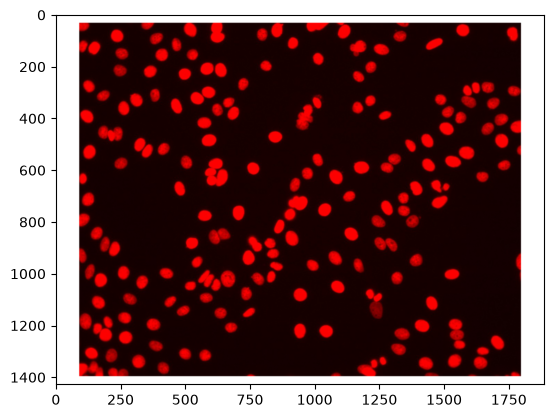

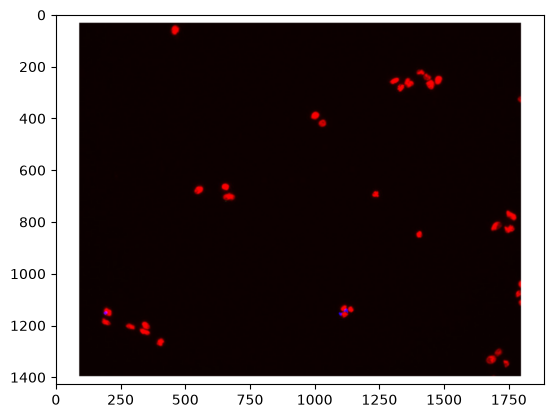

In [60]:
#Creating variables for the path names
treated_path='/Users/Dylan/Downloads/IPBR Images/Week3_25441 _Staurosporin[Well C3, Field 1].png'
untreated_path='/Users/Dylan/Downloads/IPBR Images/Week3_25441_Control [Well C2, Field 1].png'

#Creating the variables of the images themselves and printing them
treated=io.imread(treated_path)
untreated=io.imread(untreated_path)
images=[untreated, treated]
for i in images:
    plt.imshow(i)
    plt.show()

In [61]:
#Calculating the mean of each image, which tells us which image is brighter and therefore which one has the most 'stuff'. 
#This will not be the primary way of counting the objects but it serves as a good starting point
treatedMean=treated.mean()
untreatedMean=untreated.mean()
if treatedMean > untreatedMean:
    print ('treated')
else:
    print('untreated')

untreated


<function matplotlib.pyplot.show(close=None, block=None)>

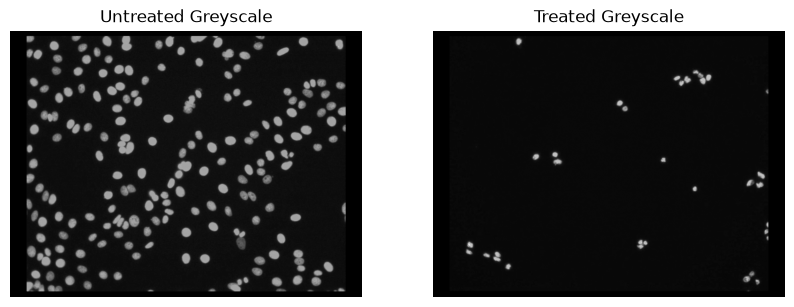

In [62]:
#Greyscaling images
grey_untreated= rgb2gray(untreated[:,:,:3])
grey_treated= rgb2gray(treated[:,:,:3])

#Plotting images
fig, ax=plt.subplots(1,2, figsize=(10,10))
ax[0].set_title('Untreated Greyscale')
ax[0].imshow(grey_untreated, cmap='grey')
ax[0].set_axis_off()
ax[1].set_title('Treated Greyscale')
ax[1].imshow(grey_treated, cmap='grey')
ax[1].set_axis_off()
plt.show

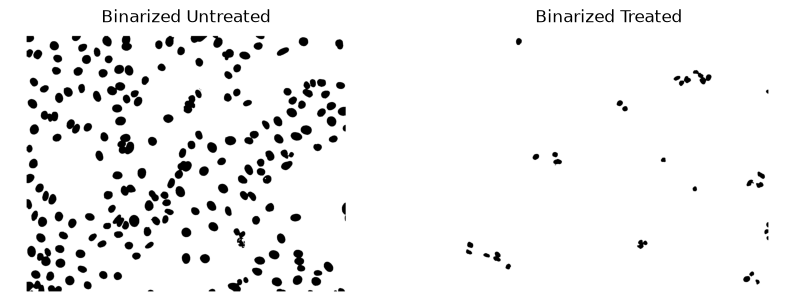

In [63]:
#Binarizing image, aka making everything strictly black or white
#This preprocessing step allows for there to be a clear delination between the cells and the background

#Use Otsu's method of calculate the best pixel cutoff point 
untreated_threshold= filters.threshold_otsu(grey_untreated)
treated_threshold= filters.threshold_otsu(grey_treated)

#Binarize based on Ostu's threshold
untreated_bw=(grey_untreated < untreated_threshold)*1
treated_bw=(grey_treated < treated_threshold)*1

#Plotting
fig, ax = plt.subplots(1,2,figsize=(10,10))
ax[0].set_title('Binarized Untreated')
ax[0].imshow(untreated_bw, cmap='gray')
ax[0].set_axis_off()
ax[1].set_title('Binarized Treated')
ax[1].imshow(treated_bw, cmap='grey')
ax[1].set_axis_off()

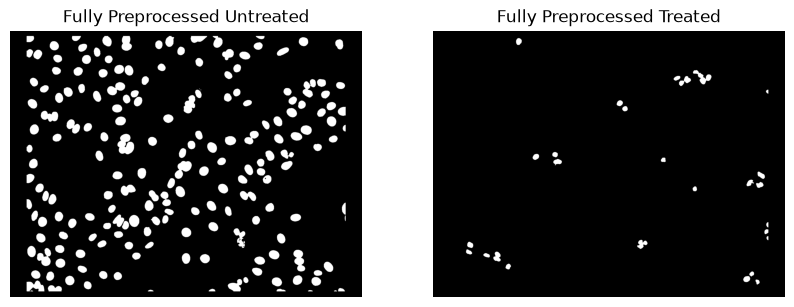

In [64]:
#Using morphological operation to seperate cells that are touching (to the best of the computers ability)

untreated_morpho= opening(untreated_bw)
treated_morpho= opening(treated_bw)

#Reversing image so that the label() function can count the cells
untreated_morpho= ~untreated_morpho
treated_morpho= ~treated_morpho

#Plot
fig,ax= plt.subplots(1,2,figsize=(10,10))
ax[0].set_title('Fully Preprocessed Untreated')
ax[0].imshow(untreated_morpho, cmap='gray')
ax[0].set_axis_off()
ax[1].set_title('Fully Preprocessed Treated')
ax[1].imshow(treated_morpho, cmap='grey')
ax[1].set_axis_off()


In [65]:
#Label each connecting pixel and get their properties
labeled_untreated= label(untreated_morpho)
untreated_properties= regionprops(labeled_untreated)
untreated_cell_count=labeled_untreated.max()

labeled_treated= label(treated_morpho)
treated_properties= regionprops(labeled_treated)
treated_cell_count=labeled_treated.max()


In [69]:
#Calculated cell death data
cell_death= untreated_cell_count - treated_cell_count
percentage_cell_death= (cell_death/untreated_cell_count)*100

In [70]:
print('=======CELL ANALYSIS RESULTS===========')
print('Untreated Cell Count', untreated_cell_count)
print('Treated Cell Count', treated_cell_count)
print('Estimated Cell Death due to Treatment', cell_death)
print('Percentage Cell Death due to Treatment', percentage_cell_death)
print('From this analysis, we can conclude that the treatment of 1 micromolar Staurosporine lead to a decrease in the number of cancer cells')

=======CELL ANALYSIS RESULTS===========
Untreated Cell Count 191
Treated Cell Count 28
Estimated Cell Death due to Treatment 163
Percentage Cell Death due to Treatment 85.34031413612566
From this analysis, we can conclude that the treatment of 1 micromolar Staurosporine lead to a decrease in the number of cancer cells
